# Bridge Notebook 01  
# From DNA/RNA Sequences to Numerical Features

This notebook is a practical bridge between **biological data representation** and **genomics**.

The main idea is simple:

```text
Biological sequence
↓
Computational object
↓
Counts
↓
Frequencies
↓
k-mers
↓
Feature vector
↓
Feature matrix
↓
Sample comparison
```

In the next module, we will use the same logic to represent **genomic differences** between individuals as **genetic variants**.

## Learning objectives

By the end of this notebook, you should be able to:

1. Represent DNA and RNA sequences as strings.
2. Validate whether a sequence follows an expected biological alphabet.
3. Count nucleotides and compute nucleotide frequencies.
4. Calculate simple sequence properties such as GC content and AT content.
5. Compare two DNA sequences position by position.
6. Detect simple sequence differences.
7. Generate k-mers from DNA and RNA sequences.
8. Convert sequences into k-mer feature vectors.
9. Build a feature matrix from multiple biological samples.
10. Compare samples using simple numerical distances.

---

# 0. Notebook setup

We will use only basic Python libraries plus `pandas`, `numpy`, and `matplotlib`.

This keeps the notebook focused on concepts, not on advanced software tools.

In [4]:
from collections import Counter
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---

# 1. Biological sequences as text

A biological sequence can be represented as a **string**.

In Python, a string is a sequence of characters.
For DNA, each character corresponds to a nucleotide:

```text
A, C, G, T
```

In [5]:
dna = "ATGCGTACGTTAGC"
dna

'ATGCGTACGTTAGC'

## 1.1 Sequence length

The length of a DNA sequence corresponds to the number of nucleotides.

In [6]:
len(dna)

14

In [7]:
number_of_base = 0
for base in dna:
    number_of_base+=1
print(number_of_base)

14


## 1.2 Accessing positions

Python uses **zero-based indexing**.

That means:

```text
Python index:         0 1 2 3 4 ...
Biological position:  1 2 3 4 5 ...
```

This is very important when we later discuss variants.

In [8]:
print("First nucleotide:", dna[0])
print("Second nucleotide:", dna[1])
print("First three nucleotides:", dna[0:3])

First nucleotide: A
Second nucleotide: T
First three nucleotides: ATG


### Mini-question

What is the biological position of `dna[3]`?

In [9]:
python_index = 3
biological_position = python_index + 1

print("Python index:", python_index)
print("Biological position:", biological_position)
print("Nucleotide:", dna[python_index])

Python index: 3
Biological position: 4
Nucleotide: C


---

# 2. DNA alphabet and sequence validation

Before analyzing biological data, we often need to check if the data follows the expected format.

For DNA, the expected alphabet is:

```text
A, C, G, T
```

In [10]:
dna_alphabet = {"A", "C", "G", "T"}
dna_alphabet

{'A', 'C', 'G', 'T'}

In [11]:
DNA_ALPHABET = {"A", "C", "G", "T"}

## 2.1 Validating a DNA sequence

A simple DNA validation function checks whether all symbols in a sequence belong to the DNA alphabet.

In [12]:
def is_valid_dna(sequence):
    """
        Return True if a sequence contains only DNA symbols.
    """
    sequence = sequence.upper()
    return set(sequence).issubset(dna_alphabet)

In [13]:
print(is_valid_dna("ATGCGT"))
print(is_valid_dna("ATGCBT"))

True
False


## 2.2 Making validation more informative

Instead of only returning `True` or `False`, we can report which symbols are unexpected.

In [14]:
def validate_dna(sequence=""):
    """Validate a DNA sequence and report unexpected symbols."""
    sequence = sequence.upper()
    observed_symbols = set(sequence)
    invalid_symbols = observed_symbols - {"A", "C", "G", "T"}

    return {
        "sequence" : sequence,
        "is_valid": len(invalid_symbols) == 0,
        "observed_symbols": sorted(observed_symbols),
        "invalid_symbols": sorted(invalid_symbols),
        "len" : len(sequence)
    }

In [15]:
validate_dna()

{'sequence': '',
 'is_valid': True,
 'observed_symbols': [],
 'invalid_symbols': [],
 'len': 0}

In [16]:
my_sequences = [
    "ATRGTT",
    "ATATATACTCT",
    "ACACACACGGTT",
    "AHHHAA"
]

my_sequences

['ATRGTT', 'ATATATACTCT', 'ACACACACGGTT', 'AHHHAA']

In [17]:
evaluated_seq = []

for sequence in my_sequences:
    evaluated_seq.append(validate_dna(sequence))

df = pd.DataFrame(evaluated_seq)
df

,sequence,is_valid,observed_symbols,invalid_symbols,len
0,ATRGTT,False,"[A, G, R, T]",[R],6
1,ATATATACTCT,True,"[A, C, T]",[],11
2,ACACACACGGTT,True,"[A, C, G, T]",[],12
3,AHHHAA,False,"[A, H]",[H],6


In [18]:
df["invalid_symbols"][0]

['R']

In [19]:
evaluated_seq

[{'sequence': 'ATRGTT',
  'is_valid': False,
  'observed_symbols': ['A', 'G', 'R', 'T'],
  'invalid_symbols': ['R'],
  'len': 6},
 {'sequence': 'ATATATACTCT',
  'is_valid': True,
  'observed_symbols': ['A', 'C', 'T'],
  'invalid_symbols': [],
  'len': 11},
 {'sequence': 'ACACACACGGTT',
  'is_valid': True,
  'observed_symbols': ['A', 'C', 'G', 'T'],
  'invalid_symbols': [],
  'len': 12},
 {'sequence': 'AHHHAA',
  'is_valid': False,
  'observed_symbols': ['A', 'H'],
  'invalid_symbols': ['H'],
  'len': 6}]

### Conceptual message

Data validation is one of the first steps in computational biology.

Before extracting features, we should ask:

```text
Does this sequence look like the type of biological object I expect?
```

---

# 3. Counting DNA symbols

One of the simplest ways to transform a sequence into data is to count how often each symbol appears.

In [20]:
Counter(dna)

Counter({'T': 4, 'G': 4, 'A': 3, 'C': 3})

## 3.1 Explicit nucleotide counts

We can force the output to always use the same nucleotide order:

```text
A, C, G, T
```

In [21]:
def nucleotide_counts(sequence):
    """Count A, C, G and T in a DNA sequence."""
    sequence = sequence.upper()
    counts = Counter(sequence)

    return {
        base: counts[base]
        for base in ["A", "C", "G", "T"]
    }

In [22]:
dna_counts = nucleotide_counts(dna)
dna_counts

{'A': 3, 'C': 3, 'G': 4, 'T': 4}

## 3.2 Convert counts to a table

In [23]:
dna_counts_table = pd.DataFrame(
    dna_counts.items(),
    columns=["base", "count"]
)

dna_counts_table

,base,count
0,A,3
1,C,3
2,G,4
3,T,4


## 3.3 Simple bar plot

A plot can help us inspect the composition of the sequence.

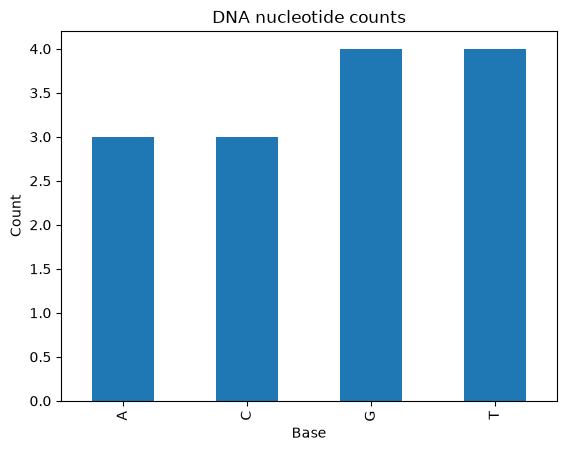

In [24]:
dna_counts_table.plot(
    x="base",
    y="count",
    kind="bar",
    legend=False
)

plt.xlabel("Base")
plt.ylabel("Count")
plt.title("DNA nucleotide counts")
plt.show()

### Conceptual message

A sequence can be summarized by the number of times each nucleotide appears.

This is one of the simplest examples of **feature extraction**.

---

# 4. From counts to frequencies

Raw counts depend on sequence length.

For example, a long sequence may have more `A` nucleotides simply because it is longer.

Frequencies normalize counts by sequence length.

In [25]:
def nucleotide_frequencies(sequence):
    """Compute A, C, G and T frequencies in a DNA sequence."""
    counts = nucleotide_counts(sequence)
    total = len(sequence)

    return {
        base: counts[base] / total
        for base in ["A", "C", "G", "T"]
    }

In [26]:
dna_frequencies = nucleotide_frequencies(dna)
dna_frequencies

{'A': 0.21428571428571427,
 'C': 0.21428571428571427,
 'G': 0.2857142857142857,
 'T': 0.2857142857142857}

## 4.1 Frequency table

In [27]:
dna_frequency_table = pd.DataFrame(
    dna_frequencies.items(),
    columns=["base", "frequency"]
)

dna_frequency_table

,base,frequency
0,A,0.214286
1,C,0.214286
2,G,0.285714
3,T,0.285714


## 4.2 Frequency vector

Once we fix the order of features, we can represent the DNA sequence as a numerical vector.

Feature order:

```text
[A_freq, C_freq, G_freq, T_freq]
```

In [28]:
dna_frequency_vector = [
    dna_frequencies["A"],
    dna_frequencies["C"],
    dna_frequencies["G"],
    dna_frequencies["T"]
]

dna_frequency_vector

[0.21428571428571427,
 0.21428571428571427,
 0.2857142857142857,
 0.2857142857142857]

The sequence:

```text
ATGCGTACGTTAGC
```

has now been transformed into a numerical representation:

```text
[A_freq, C_freq, G_freq, T_freq]
```

---

# 5. Simple DNA properties

Some biological properties can also be represented as numbers.

For DNA, two very simple examples are:

- GC content
- AT content

## 5.1 GC content

GC content is the fraction of nucleotides that are either `G` or `C`.

```text
GC content = (number of G + number of C) / sequence length
```

In [29]:
def gc_content(sequence):
    """Calculate GC content of a DNA sequence."""
    sequence = sequence.upper()
    gc = sequence.count("G") + sequence.count("C")
    return gc / len(sequence)

In [30]:
gc_content(dna)

0.5

## 5.2 AT content

AT content is the fraction of nucleotides that are either `A` or `T`.

In [31]:
def at_content(sequence):
    """Calculate AT content of a DNA sequence."""
    sequence = sequence.upper()
    at = sequence.count("A") + sequence.count("T")
    return at / len(sequence)

In [32]:
at_content(dna)

0.5

## 5.3 DNA summary features

Now we can summarize a DNA sequence using several numerical features.

In [33]:
def dna_summary_features(sequence):
    """Return a dictionary with simple DNA sequence features."""
    freqs = nucleotide_frequencies(sequence)

    return {
        "length": len(sequence),
        "A_freq": freqs["A"],
        "C_freq": freqs["C"],
        "G_freq": freqs["G"],
        "T_freq": freqs["T"],
        "GC_content": gc_content(sequence),
        "AT_content": at_content(sequence)
    }

In [34]:
dna_summary_features(dna)

{'length': 14,
 'A_freq': 0.21428571428571427,
 'C_freq': 0.21428571428571427,
 'G_freq': 0.2857142857142857,
 'T_freq': 0.2857142857142857,
 'GC_content': 0.5,
 'AT_content': 0.5}

### Conceptual message

This is a key idea for bioinformatics:

```text
Biological object → numerical features
```

Once a sequence is transformed into numerical features, it can be stored in a table, compared with other sequences, or used in a machine learning model.

---

# 6. Comparing two DNA sequences

Before comparing whole genomes, we can start with two short DNA sequences.

In [35]:
seq_a = "ATGCTAGC"
seq_b = "ATGTTAGC"

print(seq_a)
print(seq_b)

ATGCTAGC
ATGTTAGC


## 6.1 Position-by-position comparison

In [36]:
for i, (base_a, base_b) in enumerate(zip(seq_a, seq_b)):
    print(i, base_a, base_b)

0 A A
1 T T
2 G G
3 C T
4 T T
5 A A
6 G G
7 C C


In [37]:
for i, (base_a, base_b) in enumerate(zip(seq_a, seq_b)):
    print(i, base_a, base_b, base_a == base_b)

0 A A True
1 T T True
2 G G True
3 C T False
4 T T True
5 A A True
6 G G True
7 C C True


The previous output uses Python indexes.

For biological interpretation, it is often clearer to report biological positions starting from 1.

In [38]:
def compare_sequences_position_by_position(seq1, seq2):
    """Compare two sequences position by position."""
    if len(seq1) != len(seq2):
        raise ValueError("Sequences must have the same length for position-by-position comparison.")

    rows = []

    for i, (a, b) in enumerate(zip(seq1, seq2)):
        rows.append({
            "python_index": i,
            "biological_position": i + 1,
            "seq1_base": a,
            "seq2_base": b,
            "same": a == b
        })

    return pd.DataFrame(rows)

In [39]:
comparison_table = compare_sequences_position_by_position(seq_a, seq_b)
comparison_table

,python_index,biological_position,seq1_base,seq2_base,same
0,0,1,A,A,True
1,1,2,T,T,True
2,2,3,G,G,True
3,3,4,C,T,False
4,4,5,T,T,True
5,5,6,A,A,True
6,6,7,G,G,True
7,7,8,C,C,True


## 6.2 Detecting differences

In [40]:
def find_differences(seq1, seq2):
    """Find positions where two sequences are different."""
    comparison = compare_sequences_position_by_position(seq1, seq2)
    return comparison[comparison["same"] == False].reset_index(drop=True)

In [41]:
find_differences(seq_a, seq_b)

,python_index,biological_position,seq1_base,seq2_base,same
0,3,4,C,T,False


### Conceptual bridge to genomics

A single nucleotide difference between two sequences is the basic idea behind a **single nucleotide variant**.

Later, in the genomics module, we will study these differences more formally as:

- SNPs
- indels
- structural variants
- genotypes
- variant matrices

---

# 7. DNA k-mers

A **k-mer** is a subsequence of length `k`.

For DNA, k-mers are short nucleotide words.

Example:

```text
Sequence: ATGCT
k = 2 → AT, TG, GC, CT
k = 3 → ATG, TGC, GCT
```

## 7.1 Function to generate k-mers

In [42]:
def get_kmers(sequence, k):
    """Generate all k-mers of length k from a sequence."""
    if k <= 0:
        raise ValueError("k must be a positive integer.")
    if k > len(sequence):
        return []

    return [
        sequence[i:i+k]
        for i in range(len(sequence) - k + 1)
    ]

In [43]:
example_sequence = "ATGCT"

print("k = 2:", get_kmers(example_sequence, k=2))
print("k = 3:", get_kmers(example_sequence, k=3))

k = 2: ['AT', 'TG', 'GC', 'CT']
k = 3: ['ATG', 'TGC', 'GCT']


## 7.2 Counting k-mers

In [44]:
dna_kmers_k2 = get_kmers(dna, k=2)
dna_kmer_counts_k2 = Counter(dna_kmers_k2)

dna_kmer_counts_k2

Counter({'GC': 2,
         'CG': 2,
         'GT': 2,
         'TA': 2,
         'AT': 1,
         'TG': 1,
         'AC': 1,
         'TT': 1,
         'AG': 1})

## 7.3 k-mer count table

In [45]:
dna_kmer_table_k2 = pd.DataFrame(
    dna_kmer_counts_k2.items(),
    columns=["kmer", "count"]
).sort_values("kmer").reset_index(drop=True)

dna_kmer_table_k2

,kmer,count
0,AC,1
1,AG,1
2,AT,1
3,CG,2
4,GC,2
5,GT,2
6,TA,2
7,TG,1
8,TT,1


## 7.4 k-mers with different values of k

Different values of `k` capture different levels of local sequence pattern.

In [46]:
for k in [1, 2, 3, 4]:
    kmers = get_kmers(dna, k=k)
    print("k =", k)
    print(kmers)
    print()

k = 1
['A', 'T', 'G', 'C', 'G', 'T', 'A', 'C', 'G', 'T', 'T', 'A', 'G', 'C']

k = 2
['AT', 'TG', 'GC', 'CG', 'GT', 'TA', 'AC', 'CG', 'GT', 'TT', 'TA', 'AG', 'GC']

k = 3
['ATG', 'TGC', 'GCG', 'CGT', 'GTA', 'TAC', 'ACG', 'CGT', 'GTT', 'TTA', 'TAG', 'AGC']

k = 4
['ATGC', 'TGCG', 'GCGT', 'CGTA', 'GTAC', 'TACG', 'ACGT', 'CGTT', 'GTTA', 'TTAG', 'TAGC']



### Conceptual message

k-mers allow us to represent a biological sequence as a collection of short words.

This idea is used in many areas of bioinformatics, including:

- sequence comparison
- genome classification
- metagenomics
- motif discovery
- machine learning with biological sequences

---

# 8. k-mer profiles as feature vectors

To compare multiple sequences, we need all sequences to use the same set of columns.

This means we need a fixed **k-mer vocabulary**.

## 8.1 Creating a DNA k-mer vocabulary

For DNA and `k = 2`, there are:

```text
4² = 16 possible k-mers
```

In [47]:
def build_kmer_vocabulary(alphabet, k):
    """Build all possible k-mers from an alphabet."""
    return [
        "".join(kmer)
        for kmer in itertools.product(alphabet, repeat=k)
    ]

In [48]:
dna_bases = ["A", "C", "G", "T"]

k = 2
dna_kmer_vocab_k2 = build_kmer_vocabulary(dna_bases, k=k)

dna_kmer_vocab_k2

['AA',
 'AC',
 'AG',
 'AT',
 'CA',
 'CC',
 'CG',
 'CT',
 'GA',
 'GC',
 'GG',
 'GT',
 'TA',
 'TC',
 'TG',
 'TT']

## 8.2 Convert one sequence into a k-mer vector

In [49]:
def kmer_vector(sequence, k, vocabulary):
    """Convert a sequence into a k-mer count vector using a fixed vocabulary."""
    observed_kmers = get_kmers(sequence, k)
    counts = Counter(observed_kmers)

    return [
        counts[kmer]
        for kmer in vocabulary
    ]

In [50]:
dna_kmer_vector_k2 = kmer_vector(
    sequence=dna,
    k=2,
    vocabulary=dna_kmer_vocab_k2
)

dna_kmer_vector_k2

[0, 1, 1, 1, 0, 0, 2, 0, 0, 2, 0, 2, 2, 0, 1, 1]

## 8.3 Convert the vector into a table

In [51]:
pd.DataFrame(
    [dna_kmer_vector_k2],
    columns=dna_kmer_vocab_k2
)

,AA,AC,AG,AT,CA,CC,CG,CT,GA,GC,GG,GT,TA,TC,TG,TT
0,0,1,1,1,0,0,2,0,0,2,0,2,2,0,1,1


### Conceptual message

Now the DNA sequence is represented as a vector where each column corresponds to a possible k-mer.

```text
Sequence → k-mer counts → numerical vector
```

---

# 9. Multiple DNA sequences as a dataset

In real bioinformatics problems, we usually work with many sequences or many samples.

Here we will create a small synthetic dataset.

In [52]:
samples = {
    "P001": "ATGCGTACGTTAGC",
    "P002": "ATGCGTACGATAGC",
    "P003": "ATGCGTACGCTAGC",
    "P004": "TTGCGTACGTTAAA"
}

samples

{'P001': 'ATGCGTACGTTAGC',
 'P002': 'ATGCGTACGATAGC',
 'P003': 'ATGCGTACGCTAGC',
 'P004': 'TTGCGTACGTTAAA'}

## 9.1 Add simple metadata

Metadata provides information about each sample.

Here we use a simple group label:

```text
Healthy / Diseased
```

In [53]:
metadata = pd.DataFrame({
    "sample_id": ["P001", "P002", "P003", "P004"],
    "group": ["Healthy", "Healthy", "Diseased", "Diseased"]
})

metadata

,sample_id,group
0,P001,Healthy
1,P002,Healthy
2,P003,Diseased
3,P004,Diseased


## 9.2 Build simple feature rows

Each sample will be converted into a row of numerical features.

In [54]:
feature_rows = []

for sample_id, sequence in samples.items():
    row = {"sample_id": sample_id}
    row.update(dna_summary_features(sequence))
    feature_rows.append(row)

features = pd.DataFrame(feature_rows)
features

,sample_id,length,A_freq,C_freq,G_freq,T_freq,GC_content,AT_content
0,P001,14,0.214286,0.214286,0.285714,0.285714,0.500000,0.500000
1,P002,14,0.285714,0.214286,0.285714,0.214286,0.500000,0.500000
2,P003,14,0.214286,0.285714,0.285714,0.214286,0.571429,0.428571
3,P004,14,0.285714,0.142857,0.214286,0.357143,0.357143,0.642857


## 9.3 Merge metadata and features

In [55]:
feature_table = metadata.merge(features, on="sample_id")
feature_table

,sample_id,group,length,A_freq,C_freq,G_freq,T_freq,GC_content,AT_content
0,P001,Healthy,14,0.214286,0.214286,0.285714,0.285714,0.500000,0.500000
1,P002,Healthy,14,0.285714,0.214286,0.285714,0.214286,0.500000,0.500000
2,P003,Diseased,14,0.214286,0.285714,0.285714,0.214286,0.571429,0.428571
3,P004,Diseased,14,0.285714,0.142857,0.214286,0.357143,0.357143,0.642857


### Conceptual message

This table is a **feature matrix**.

```text
Rows    → samples
Columns → biological features
```

This is one of the most common data structures in bioinformatics and machine learning.

---

# 10. DNA k-mer matrix

Now we will build a feature matrix using k-mer counts.

Each row will be a sample.
Each column will be a possible k-mer.

In [56]:
k = 2
vocabulary = build_kmer_vocabulary(dna_bases, k=k)

kmer_feature_rows = []

for sample_id, sequence in samples.items():
    vector = kmer_vector(sequence, k=k, vocabulary=vocabulary)

    row = {"sample_id": sample_id}
    row.update({
        kmer: value
        for kmer, value in zip(vocabulary, vector)
    })

    kmer_feature_rows.append(row)

kmer_matrix = pd.DataFrame(kmer_feature_rows)
kmer_matrix

,sample_id,AA,AC,AG,AT,CA,CC,CG,CT,GA,GC,GG,GT,TA,TC,TG,TT
0,P001,0,1,1,1,0,0,2,0,0,2,0,2,2,0,1,1
1,P002,0,1,1,2,0,0,2,0,1,2,0,1,2,0,1,0
2,P003,0,1,1,1,0,0,2,1,0,3,0,1,2,0,1,0
3,P004,2,1,0,0,0,0,2,0,0,1,0,2,2,0,1,2


## 10.1 Merge k-mer matrix with metadata

In [57]:
kmer_feature_table = metadata.merge(kmer_matrix, on="sample_id")
kmer_feature_table

,sample_id,group,AA,AC,AG,AT,CA,CC,CG,CT,GA,GC,GG,GT,TA,TC,TG,TT
0,P001,Healthy,0,1,1,1,0,0,2,0,0,2,0,2,2,0,1,1
1,P002,Healthy,0,1,1,2,0,0,2,0,1,2,0,1,2,0,1,0
2,P003,Diseased,0,1,1,1,0,0,2,1,0,3,0,1,2,0,1,0
3,P004,Diseased,2,1,0,0,0,0,2,0,0,1,0,2,2,0,1,2


### Conceptual message

This is a sequence-derived numerical representation.

Each patient is represented by a profile of DNA words.

---

# 11. Comparing samples using distances

Once sequences are converted into numerical vectors, we can compare them using numerical distances.

Here we will use Euclidean distance as a simple example.

## 11.1 Extract the numerical matrix

In [58]:
X = kmer_feature_table[vocabulary].values
X

array([[0, 1, 1, 1, 0, 0, 2, 0, 0, 2, 0, 2, 2, 0, 1, 1],
       [0, 1, 1, 2, 0, 0, 2, 0, 1, 2, 0, 1, 2, 0, 1, 0],
       [0, 1, 1, 1, 0, 0, 2, 1, 0, 3, 0, 1, 2, 0, 1, 0],
       [2, 1, 0, 0, 0, 0, 2, 0, 0, 1, 0, 2, 2, 0, 1, 2]])

## 11.2 Euclidean distance

Euclidean distance between two vectors is calculated as:

```text
distance(x, y) = sqrt(sum((x_i - y_i)^2))
```

In [59]:
def euclidean_distance(x, y):
    """Calculate Euclidean distance between two numerical vectors."""
    x = np.array(x)
    y = np.array(y)
    return np.sqrt(np.sum((x - y) ** 2))

In [60]:
euclidean_distance(X[0], X[1])

np.float64(2.0)

## 11.3 Pairwise distance matrix

In [61]:
sample_ids = kmer_feature_table["sample_id"].tolist()

pairwise_distances = pd.DataFrame(
    np.zeros((len(sample_ids), len(sample_ids))),
    index=sample_ids,
    columns=sample_ids
)

for i in range(len(sample_ids)):
    for j in range(len(sample_ids)):
        pairwise_distances.iloc[i, j] = euclidean_distance(X[i], X[j])

pairwise_distances

,P001,P002,P003,P004
P001,0.000000,2.0,2.0,2.828427
P002,2.000000,0.0,2.0,4.000000
P003,2.000000,2.0,0.0,4.000000
P004,2.828427,4.0,4.0,0.000000


### Conceptual message

A distance matrix summarizes how similar or different samples are from each other.

This will be useful later when we compare patients, genomes and variant profiles.

---

# 12. RNA sequences

RNA can be represented using the same computational logic as DNA.

The main alphabet difference is:

```text
DNA uses T
RNA uses U
```

## 12.1 DNA to RNA transcription

In a simplified coding-strand representation, we can convert DNA to RNA by replacing `T` with `U`.

In [62]:
def transcribe_dna_to_rna(sequence):
    """Convert a DNA coding sequence into an RNA sequence by replacing T with U."""
    sequence = sequence.upper()
    return sequence.replace("T", "U")

In [63]:
rna = transcribe_dna_to_rna(dna)
rna

'AUGCGUACGUUAGC'

## 12.2 RNA alphabet and validation

In [64]:
rna_alphabet = {"A", "C", "G", "U"}
rna_alphabet

{'A', 'C', 'G', 'U'}

In [65]:
def is_valid_rna(sequence):
    """Return True if a sequence contains only RNA symbols."""
    sequence = sequence.upper()
    return set(sequence).issubset({"A", "C", "G", "U"})

In [66]:
print(is_valid_rna("AUGCGU"))
print(is_valid_rna("ATGCGT"))

True
False


## 12.3 RNA counts and frequencies

In [67]:
def rna_nucleotide_counts(sequence):
    """Count A, C, G and U in an RNA sequence."""
    sequence = sequence.upper()
    counts = Counter(sequence)

    return {
        base: counts[base]
        for base in ["A", "C", "G", "U"]
    }

In [68]:
def rna_nucleotide_frequencies(sequence):
    """Compute A, C, G and U frequencies in an RNA sequence."""
    counts = rna_nucleotide_counts(sequence)
    total = len(sequence)

    return {
        base: counts[base] / total
        for base in ["A", "C", "G", "U"]
    }

In [69]:
rna_counts = rna_nucleotide_counts(rna)
rna_frequencies = rna_nucleotide_frequencies(rna)

print("Counts:", rna_counts)
print("Frequencies:", rna_frequencies)

Counts: {'A': 3, 'C': 3, 'G': 4, 'U': 4}
Frequencies: {'A': 0.21428571428571427, 'C': 0.21428571428571427, 'G': 0.2857142857142857, 'U': 0.2857142857142857}


## 12.4 RNA k-mers

In [70]:
get_kmers(rna, k=3)

['AUG',
 'UGC',
 'GCG',
 'CGU',
 'GUA',
 'UAC',
 'ACG',
 'CGU',
 'GUU',
 'UUA',
 'UAG',
 'AGC']

## 12.5 RNA k-mer vector

In [71]:
rna_bases = ["A", "C", "G", "U"]

rna_kmer_vocab_k2 = build_kmer_vocabulary(rna_bases, k=2)
rna_kmer_vector_k2 = kmer_vector(rna, k=2, vocabulary=rna_kmer_vocab_k2)

pd.DataFrame(
    [rna_kmer_vector_k2],
    columns=rna_kmer_vocab_k2
)

,AA,AC,AG,AU,CA,CC,CG,CU,GA,GC,GG,GU,UA,UC,UG,UU
0,0,1,1,1,0,0,2,0,0,2,0,2,2,0,1,1


### Conceptual message

DNA and RNA can be represented using the same computational framework:

```text
sequence → counts → frequencies → k-mers → vector
```

Only the biological alphabet changes.

---

# 13. Final integration

The same computational logic can be applied to different types of biological sequences.

In this notebook, we focused on DNA and RNA.

## 13.1 Summary table

| Molecule | Alphabet | Simple features | k-mers | Feature matrix possible |
|---|---|---|---|---|
| DNA | A, C, G, T | length, nucleotide frequencies, GC content, AT content | Yes | Yes |
| RNA | A, C, G, U | length, nucleotide frequencies | Yes | Yes |

## 13.2 Main conceptual flow

```text
DNA/RNA sequence
↓
Counts
↓
Frequencies
↓
k-mers
↓
Feature vector
↓
Feature matrix
↓
Sample comparison
```

## 13.3 Bridge to genomics

In this notebook, we represented DNA and RNA sequences as numerical features.

In the next module, we will apply the same logic to genomes.

Instead of only counting symbols or k-mers, we will identify genetic differences between individuals and represent those differences as variants.

```text
sequence features → variant features
sequence matrix   → variant matrix
sample comparison → patient comparison
```

---

# 14. Student exercises

These exercises are designed to reinforce the main concepts of the notebook.

## Exercise 1: Basic DNA features

Given the sequence below, compute:

1. sequence length
2. A, C, G and T counts
3. nucleotide frequencies
4. GC content
5. AT content

In [72]:
exercise_seq_1 = "ATGCGCGTTAAC"

# Your code here

## Exercise 2: DNA k-mers

For the sequence below, generate all k-mers using:

- `k = 2`
- `k = 3`

In [73]:
exercise_seq_2 = "ATGCGT"

# Your code here

## Exercise 3: Build a DNA feature table

Given the following sequences, build a feature table with:

- sample ID
- sequence length
- A frequency
- C frequency
- G frequency
- T frequency
- GC content

In [74]:
exercise_sequences = {
    "S1": "ATGCGT",
    "S2": "ATGAGT",
    "S3": "TTGCGC"
}

# Your code here

## Exercise 4: Build a DNA k-mer matrix

Using the sequences from Exercise 3, build a k-mer matrix using:

```python
k = 2
```

In [75]:
# Your code here

## Exercise 5: Compare two DNA sequences

Compare the following sequences position by position and identify the differences.

In [76]:
exercise_seq_a = "ATGCTAGC"
exercise_seq_b = "ATGTTAGC"

# Your code here

## Exercise 6: DNA to RNA

Transcribe the following DNA sequence into RNA, then compute RNA nucleotide counts and RNA k-mers with `k = 3`.

In [77]:
exercise_dna = "ATGCGTACGTTA"

# Your code here

---

# End of notebook

Main takeaway:

```text
DNA/RNA sequences can be transformed into numerical representations.
These representations can be organized as vectors and matrices.
This is the foundation for comparing biological samples computationally.
```